## Lab 01 - ANN DL - Custom Image Data Loader 

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.datasets import make_regression
from sklearn import metrics
from sklearn import decomposition
from sklearn import manifold
from tqdm.notebook import trange, tqdm

#TensorFlow and Keras Libraries
import tensorflow as tf
from tensorflow.keras.layers import Dense, Flatten, Conv2D
from tensorflow.keras import Model
import torch
from torchvision import transforms
from tensorflow.keras.utils import to_categorical
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data
import torchvision
import torchvision.datasets as datasets
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os

# Hiding the warnings
import warnings
warnings.filterwarnings('ignore')

# Extra Libraries
import copy
import random
import time

# Linkl to the dataset : https://github.com/ywchiu/riii/blob/master/data/house-prices.csv

In [7]:
# Path to dataset
dataset_path = "DataBase\Image_Data"

# Image transformations
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.125, 0.125, 0.125])
])

class CatsDogsSnakesDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.images = []
        self.labels = []

        # Load all images from the "cats" folder
        cat_folder = os.path.join(root_dir, "cats")
        for file in os.listdir(cat_folder):
            if file.endswith(('jpg', 'png', 'jpeg')):
                self.images.append(os.path.join(cat_folder, file))
                self.labels.append(0)  # 0 for Cats

        # Load all images from the "dogs" folder
        dog_folder = os.path.join(root_dir, "dogs")
        for file in os.listdir(dog_folder):
            if file.endswith(('jpg', 'png', 'jpeg')):
                self.images.append(os.path.join(dog_folder, file))
                self.labels.append(1)  # 1 for Dogs

        # Load all images from the "Snake" folder
        snake_folder = os.path.join(root_dir, "snakes")
        for file in os.listdir(snake_folder):
            if file.endswith(('jpg', 'png', 'jpeg')):
                self.images.append(os.path.join(snake_folder, file))
                self.labels.append(2)  # 2 for Snakes

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        # Load image and label
        img_path = self.images[idx]
        label = self.labels[idx]

        # Open image
        image = Image.open(img_path).convert("RGB")

        # Apply transformations if any
        if self.transform:
            image = self.transform(image)

        # Convert label to tensor
        label = torch.tensor(label, dtype=torch.long)

        # Return image and label
        return image, label

# Instantiate Dataset
dataset = CatsDogsSnakesDataset(dataset_path, transform=transform)

# DataLoader
dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

# Test the DataLoader
for images, labels in dataloader:
    print(f"Batch size: {images.shape}, Labels: {labels}")
    break

Batch size: torch.Size([64, 3, 256, 256]), Labels: tensor([1, 1, 1, 0, 0, 0, 0, 2, 0, 2, 1, 1, 2, 0, 2, 1, 2, 1, 0, 0, 2, 0, 0, 1,
        2, 0, 0, 1, 1, 0, 2, 1, 1, 2, 1, 1, 2, 2, 1, 2, 1, 2, 2, 1, 2, 0, 0, 2,
        2, 2, 0, 0, 1, 1, 2, 2, 2, 1, 1, 0, 2, 1, 1, 2])


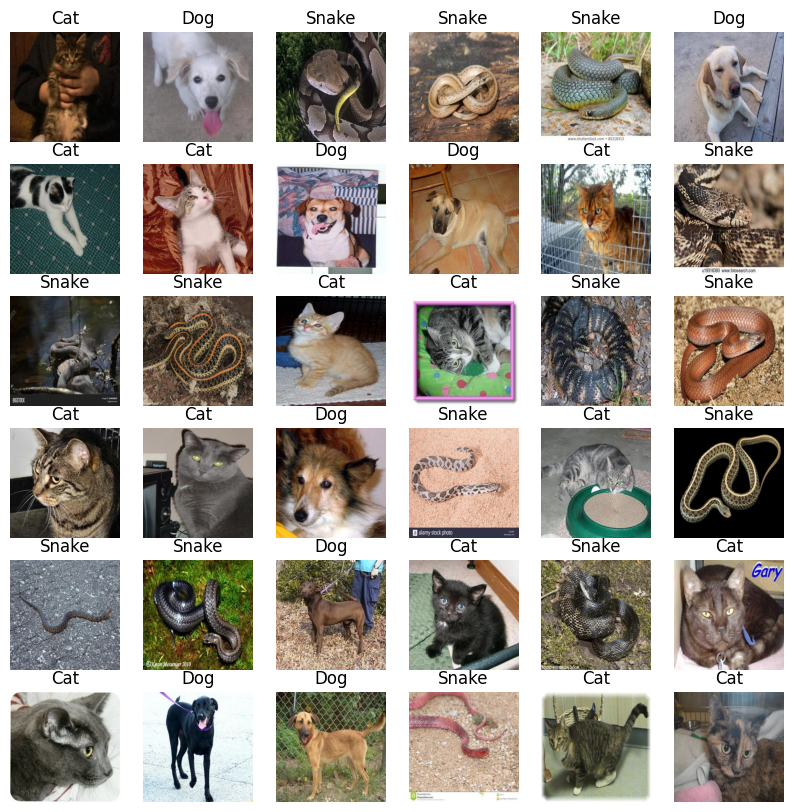

In [8]:
# Load one batch from DataLoader
images, labels = next(iter(dataloader))

# Define Class Names
class_names = ["Cat", "Dog", "Snake"]

# Plot the Images
plt.figure(figsize=(10, 10))

# Visualize 25 images (5x5 grid)
for i in range(36):
    plt.subplot(6, 6, i+1)
    img = images[i].permute(1, 2, 0)  # Change tensor shape from (C, H, W) -> (H, W, C)

    # Reverse normalization (optional)
    img = img * 0.125 + 0.5  # Because you normalized with mean=0.5 and std=0.125

    # Plot the image
    plt.imshow(img.numpy())
    plt.title(f"{class_names[labels[i].item()]}")
    plt.axis("off")

plt.show()